In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

path = r'C:\Users\babib\OneDrive\Documentos\paradigmas-programacao\sprint2\aula7\olhos_verdes.jpg'
imagem = cv2.imread(path)
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
imagem.shape

(3096, 5416, 3)

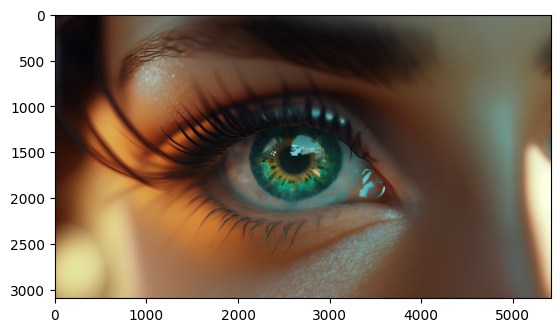

In [4]:
plt.imshow(imagem)

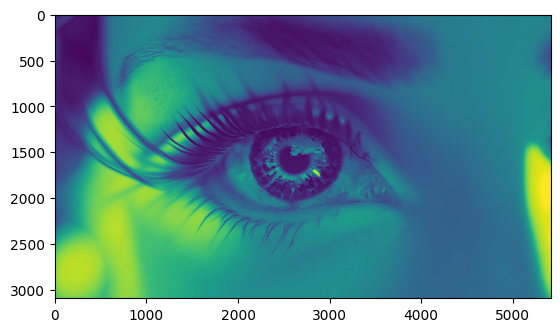

In [5]:
(r, g, b) = cv2.split(imagem)

r, g, b = r/255, g/255, b/255

plt.imshow(r)

In [6]:
pca_componentes = 50
pca_r = PCA(n_components=pca_componentes)
r_reduz = pca_r.fit_transform(r)

pca_g = PCA(n_components=pca_componentes)
g_reduz = pca_g.fit_transform(g)

pca_b = PCA(n_components=pca_componentes)
b_reduz = pca_b.fit_transform(b)

print(r_reduz.shape)
print(g_reduz.shape)
print(b_reduz.shape)
print()

(3096, 50)
(3096, 50)
(3096, 50)



In [7]:
junto = np.asarray([r_reduz, g_reduz, b_reduz])

In [8]:
recon_r = pca_r.inverse_transform(r_reduz)
recon_g = pca_g.inverse_transform(g_reduz)
recon_b = pca_b.inverse_transform(b_reduz)

recon_r.shape

(3096, 5416)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


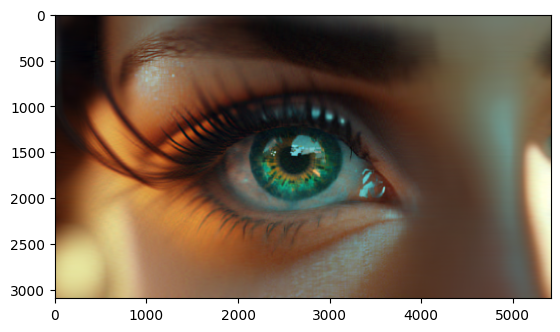

In [9]:
img_recon = cv2.merge((recon_r, recon_g, recon_b))
plt.imshow(img_recon)

In [10]:
img_salvar = np.clip(img_recon, 0, 1)
img_salvar = (img_salvar * 255).astype(np.uint8)
img_salvar = cv2.cvtColor(img_salvar, cv2.COLOR_RGB2BGR)

cv2.imwrite('teste.jpg', img_salvar)

True